# Evaluating site-to-site variability

Method 1: compare coefficient of variation across sites using 3 gridded products: PRISM, SQUIRE, and ASO.

Method 2: evaluate differences in measurements using difference in medians, difference in zero fraction, and KS statistic

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import xarray as xr
import rioxarray as rxr
import rasterio as rio
import geopandas as gpd
from pathlib import Path
import pandas as pd
from shapely.geometry import Point, Polygon
import os
from glob import glob

## Method 1: CV comparison

In [2]:
# site locations 
billy_barr_loc = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/billy_barr/billy_barr_20211001-20230930_30min.nc")[['lat', 'lon', 'alt']] 
billy_barr_pt = Point(billy_barr_loc.lon.values, billy_barr_loc.lat.values, billy_barr_loc.alt.values)

gothic_loc = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/SAIL/met_30min.nc")[['lat', 'lon', 'alt']]
gothic_pt = Point(gothic_loc.lon.values[0], gothic_loc.lat.values[0], gothic_loc.alt.values[0])

kettle_ponds_pt = Point(-106.973, 38.942, 2861) # from de Boer et al. 2023

# add crs to points
billy_barr_gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[billy_barr_pt])
gothic_gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[gothic_pt])
kettle_ponds_gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[kettle_ponds_pt])

In [3]:
def create_site_buffer(site_locs, buffer, crs):
    minx = min([site.geometry.x.values[0] - buffer for site in site_locs])
    maxx = max([site.geometry.x.values[0] + buffer for site in site_locs])
    miny = min([site.geometry.y.values[0] - buffer for site in site_locs])
    maxy = max([site.geometry.y.values[0] + buffer for site in site_locs])
    roi_polygon = Polygon([(minx, miny), (minx, maxy), (maxx, maxy), (maxx, miny)])
    roi_gdf = gpd.GeoDataFrame(index=[0], crs=crs, geometry=[roi_polygon])
    return roi_gdf, minx, maxx, miny, maxy


### PRISM
Note, PRISM may be too coarse. Think through this...

In [4]:
PRISM_PATH = "/storage/dlhogan/precipitation-rodeo/data/external/PRISM/processed"

prism_files = sorted(glob(PRISM_PATH + "/*.nc"))

# match crs of points to ASO data
billy_barr_gdf = billy_barr_gdf.to_crs('EPSG:4326')
gothic_gdf = gothic_gdf.to_crs('EPSG:4326')
kettle_ponds_gdf = kettle_ponds_gdf.to_crs('EPSG:4326')

buffer = 100/(111*1000)

site_rect, minx, maxx, miny, maxy = create_site_buffer([billy_barr_gdf, gothic_gdf, kettle_ponds_gdf], buffer, 'EPSG:4326')

datasets = []
# get the date
for i, pf in enumerate(prism_files):
    file_date = pf.split("_")[-2]
    try:
        # Use lazy loading - data not actually loaded into memory yet
        ds = xr.open_dataset(pf, chunks={'x': 'auto', 'y': 'auto'})
        ds = ds.rio.write_crs('EPSG:4326')
        # clip to site_rect
        ds = ds['ppt'].rio.clip(site_rect.geometry.values, site_rect.crs, drop=True)

        ds_with_time = ds.expand_dims(time=[pd.to_datetime(file_date, format="%Y%m%d")])
        datasets.append(ds_with_time)
        if (i + 1) % 100 == 0 or (i + 1) == len(prism_files):
            print(f"  ✓ Queued {i+1}/{len(prism_files)} datasets (not yet loaded)")
    except Exception as e:
        print(f"  ✗ Error loading {Path(pf).name}: {e}")
merged_ds = xr.concat(datasets, dim='time').compute()
# make time a dimension
merged_ds['time'] = pd.to_datetime(merged_ds['time'])

  ✓ Queued 100/730 datasets (not yet loaded)
  ✓ Queued 200/730 datasets (not yet loaded)
  ✓ Queued 300/730 datasets (not yet loaded)
  ✓ Queued 400/730 datasets (not yet loaded)
  ✓ Queued 500/730 datasets (not yet loaded)
  ✓ Queued 600/730 datasets (not yet loaded)
  ✓ Queued 700/730 datasets (not yet loaded)
  ✓ Queued 730/730 datasets (not yet loaded)


Comparing monthly precipitation across the three sites.

Over the spatial extent between sites, does precipitation vary spatially over time? 

Here I calculate the monthly CV over the area containing the sites. This is the standard deviation of the grid cells divided by their mean. 

(0.0, 1.0)

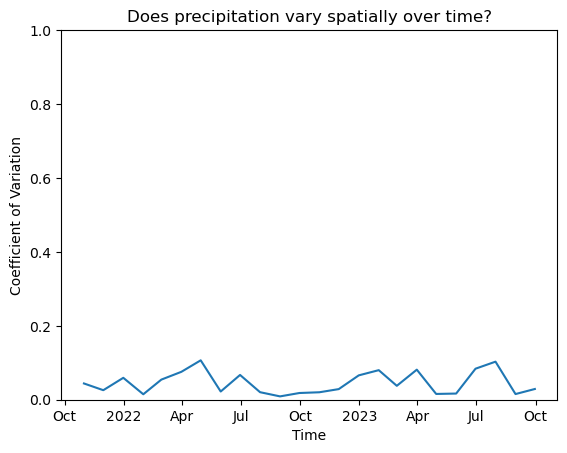

In [5]:
spatial_monthly_std = merged_ds.resample(time='1ME').sum().std(dim=['lat','lon'])
spatial_monthly_mean = merged_ds.resample(time='1ME').sum().mean(dim=['lat','lon'])
spatial_monthly_cv = spatial_monthly_std/spatial_monthly_mean

fig, ax = plt.subplots()
spatial_monthly_cv.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Does precipitation vary spatially over time?')
ax.set_ylim(0,1)

Direct spatial difference plots over the entire study period. 

### ASO data 

In [6]:
aso_path = "/storage/dlhogan/precipitation-rodeo/data/external/ASO/"

flight_2022 = aso_path + "ASO_50M_SWE.001_ER/ASO_Gunnison_EastRiver_2022Apr21_swe_50m.tif"
flight_2023 = aso_path + "ASO_EastRiver_2023Apr01_AllData_and_Reports/ASO_EastRiver_2023Apr01_swe_50m.tif"

In [7]:
aso_flight_2022 = rxr.open_rasterio(flight_2022, masked=True).squeeze()
aso_flight_2023 = rxr.open_rasterio(flight_2023, masked=True).squeeze()

In [8]:
# match crs of points to ASO data
billy_barr_gdf = billy_barr_gdf.to_crs(aso_flight_2022.rio.crs)
gothic_gdf = gothic_gdf.to_crs(aso_flight_2022.rio.crs)
kettle_ponds_gdf = kettle_ponds_gdf.to_crs(aso_flight_2022.rio.crs)

buffer = 100

site_rect, minx, maxx, miny, maxy = create_site_buffer([billy_barr_gdf, gothic_gdf, kettle_ponds_gdf], buffer, aso_flight_2022.rio.crs)


Text(162.19207146845454, 0.5, 'Northing (m)')

/home/dlhogan/miniforge3/envs/data-and-plotting/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


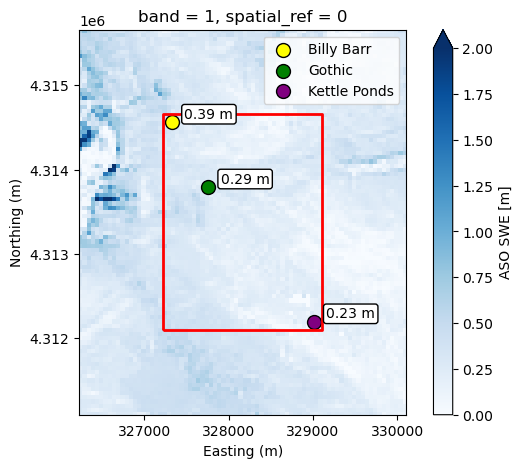

In [9]:
flight = aso_flight_2022

bb_val = flight.sel(x=billy_barr_gdf.geometry.x.values[0], y=billy_barr_gdf.geometry.y.values[0], method="nearest").values
gothic_val = flight.sel(x=gothic_gdf.geometry.x.values[0], y=gothic_gdf.geometry.y.values[0], method="nearest").values
kettle_ponds_val = flight.sel(x=kettle_ponds_gdf.geometry.x.values[0], y=kettle_ponds_gdf.geometry.y.values[0], method="nearest").values

# plot flight with rectangle
fig, ax = plt.subplots(figsize=(7,5))
flight.plot(ax=ax, cmap='Blues', vmin=0, vmax=2)
site_rect.boundary.plot(ax=ax, color='red', linewidth=2)
billy_barr_gdf.plot(ax=ax, color='yellow', ec='black', markersize=100, label='Billy Barr')
ax.text(billy_barr_gdf.geometry.x.values[0]+150, 
        billy_barr_gdf.geometry.y.values[0]+50, f"{bb_val:.2f} m", color='black',
        bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.2'))
gothic_gdf.plot(ax=ax, color='green', ec='black', markersize=100, label='Gothic')
ax.text(gothic_gdf.geometry.x.values[0]+150, 
        gothic_gdf.geometry.y.values[0]+50, f"{gothic_val:.2f} m", color='black',
        bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.2'))
kettle_ponds_gdf.plot(ax=ax, color='purple', ec='black', markersize=100, label='Kettle Ponds')
ax.text(kettle_ponds_gdf.geometry.x.values[0]+150, 
        kettle_ponds_gdf.geometry.y.values[0]+50, f"{kettle_ponds_val:.2f} m",
        color='black',
        bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.2'))
ax.legend()
ax.set_xlim(minx-1000, maxx+1000)
ax.set_xlabel("Easting (m)")
ax.set_ylim(miny-1000, maxy+1000)
ax.set_ylabel("Northing (m)")

In [10]:
# crop to roi
roi = site_rect.geometry.values
roi_gdf = site_rect.to_crs(aso_flight_2022.rio.crs)
aso_flight_2022_roi = aso_flight_2022.rio.clip(roi_gdf.geometry, roi_gdf.crs)
aso_flight_2023_roi = aso_flight_2023.rio.clip(roi_gdf.geometry, roi_gdf.crs)

# calculate the coefficient of variation within the roi for each flight
cv_2022 = (aso_flight_2022_roi.std() / aso_flight_2022_roi.mean()).values
cv_2023 = (aso_flight_2023_roi.std() / aso_flight_2023_roi.mean()).values
print(f"Coefficient of Variation 2022 Flight: {cv_2022:.2f}")
print(f"Coefficient of Variation 2023 Flight: {cv_2023:.2f}")

Coefficient of Variation 2022 Flight: 0.41
Coefficient of Variation 2023 Flight: 0.09


### SQUIRE

In [11]:
# match crs of points to ASO data
billy_barr_gdf = billy_barr_gdf.to_crs(aso_flight_2022.rio.crs)
gothic_gdf = gothic_gdf.to_crs(aso_flight_2022.rio.crs)
kettle_ponds_gdf = kettle_ponds_gdf.to_crs(aso_flight_2022.rio.crs)

buffer = 100

site_rect, minx, maxx, miny, maxy = create_site_buffer([billy_barr_gdf, gothic_gdf, kettle_ponds_gdf], buffer, aso_flight_2022.rio.crs)

In [15]:
SQUIRE_DIR = "/storage/dlhogan/precipitation-rodeo/data/raw/SAIL/updated_squire"
SQUIRE_2022 = "/storage/dlhogan/precipitation-rodeo/data/processed/squire_snowfall_total_2022.nc"
SQUIRE_2023 = "/storage/dlhogan/precipitation-rodeo/data/processed/squire_snowfall_total_2023.nc"
squire_files = sorted(glob(os.path.join(SQUIRE_DIR, "*.nc")))

if not os.path.exists(SQUIRE_2022) or not os.path.exists(SQUIRE_2023):
    from dask.distributed import get_client, Client, progress

    try:
        client = get_client()
    except ValueError:
        client = Client(n_workers=12, threads_per_worker=1)
    ds = xr.open_mfdataset(squire_files, chunks={'time': 'auto'})
    single_ds = xr.open_dataset(squire_files[0])
    snowfall_total_2022 = ds[['snow_rate_ws88diw','snow_rate_m2009_1','snow_rate_m2009_2','snow_rate_ws2012']].sel(time=slice('2021-12-01','2022-03-31')).sum(dim='time') / 12
    snowfall_total_2023 = ds[['snow_rate_ws88diw','snow_rate_m2009_1','snow_rate_m2009_2','snow_rate_ws2012']].sel(time=slice('2022-12-01','2023-03-31')).sum(dim='time') / 12
else:
    snowfall_total_2022_result = xr.open_dataset(SQUIRE_2022)
    snowfall_total_2023_result = xr.open_dataset(SQUIRE_2023)

In [16]:
import time
if not os.path.exists(SQUIRE_2022):
    snowfall_total_2022_computed = client.compute(snowfall_total_2022)
    progress(snowfall_total_2022_computed)
    # pause for 80 seconds to avoid overloading the cluster
    time.sleep(80)
    snowfall_total_2022_result = snowfall_total_2022_computed.result()
    snowfall_total_2022_result.to_netcdf("/storage/dlhogan/precipitation-rodeo/data/processed/squire_snowfall_total_2022.nc")
    

In [17]:
if not os.path.exists(SQUIRE_2023):
    snowfall_total_2023_computed = client.compute(snowfall_total_2023)
    progress(snowfall_total_2023_computed)
    # pause for 80 seconds to avoid overloading the cluster
    time.sleep(80)
    snowfall_total_2023_result = snowfall_total_2023_computed.result()
    snowfall_total_2023_result.to_netcdf("/storage/dlhogan/precipitation-rodeo/data/processed/squire_snowfall_total_2023.nc")

In [18]:
ensemble_member = 'snow_rate_ws88diw'
# build rioxarray dataset 
y = single_ds['lat'].values
x = single_ds['lon'].values
snowfall_rxr_2022 = xr.DataArray(
    data=snowfall_total_2022_result[ensemble_member].values,
    dims=["y", "x"],
    coords={"y": y, "x": x},
).rio.write_crs("EPSG:4326")

snowfall_rxr_2023 = xr.DataArray(
    data=snowfall_total_2023_result[ensemble_member].values,
    dims=["y", "x"],
    coords={"y": y, "x": x},
).rio.write_crs("EPSG:4326")

snowfall_rxr_all = xr.DataArray(
    data=(snowfall_total_2022_result[ensemble_member] + snowfall_total_2023_result[ensemble_member]).values,
    dims=["y", "x"],
    coords={"y": y, "x": x},
).rio.write_crs("EPSG:4326")

In [19]:
# convert crs to match billy barr
snowfall_rxr_2022 = snowfall_rxr_2022.rio.reproject(billy_barr_gdf.crs)
snowfall_rxr_2023 = snowfall_rxr_2023.rio.reproject(billy_barr_gdf.crs)
snowfall_rxr_all = snowfall_rxr_all.rio.reproject(billy_barr_gdf.crs)

In [20]:
bb_val = snowfall_rxr_2023.sel(x=billy_barr_gdf.geometry.x.values[0], y=billy_barr_gdf.geometry.y.values[0], method="nearest").values
gothic_val = snowfall_rxr_2023.sel(x=gothic_gdf.geometry.x.values[0], y=gothic_gdf.geometry.y.values[0], method="nearest").values
kettle_ponds_val = snowfall_rxr_2023.sel(x=kettle_ponds_gdf.geometry.x.values[0], y=kettle_ponds_gdf.geometry.y.values[0], method="nearest").values

print(kettle_ponds_val/bb_val)

0.8244693667758685


In [21]:
# crop to roi
roi = site_rect.geometry.values
roi_gdf = site_rect.to_crs(snowfall_rxr_2022.rio.crs)
snowfall_rxr_2022_roi = snowfall_rxr_2022.rio.clip(roi_gdf.geometry, roi_gdf.crs)
snowfall_rxr_2023_roi = snowfall_rxr_2023.rio.clip(roi_gdf.geometry, roi_gdf.crs)

# calculate the coefficient of variation within the roi for each flight
cv_2022 = (snowfall_rxr_2022_roi.std() / snowfall_rxr_2022_roi.mean()).values
cv_2023 = (snowfall_rxr_2023_roi.std() / snowfall_rxr_2023_roi.mean()).values
print(f"Coefficient of Variation 2022 SQUIRE: {cv_2022:.2f}")
print(f"Coefficient of Variation 2023 SQUIRE: {cv_2023:.2f}")

Coefficient of Variation 2022 SQUIRE: 0.07
Coefficient of Variation 2023 SQUIRE: 0.07


In [22]:
# custom colormap white to blue to hot pink
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", ["white", "steelblue", "fuchsia"])

In [ ]:
# Geospatial libraries
import rioxarray as rxr
import py3dep as py3d
# get hillshade for plotting
upper_east_river = gpd.read_file("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/01a_data_access/geodata/East_River_lumped_HRUs_GRUs.shp")
bounds = upper_east_river.total_bounds
topo = py3d.get_map(["DEM", "Slope Degrees", "Aspect Degrees", "Hillshade Gray"], bounds, 30, geo_crs=4326, crs=5070)
# clip topo to upper east river boundary
topo = topo.rio.clip(upper_east_river.geometry.values, upper_east_river.crs, drop=True)
# convert to 32613
topo = topo.rio.reproject("EPSG:32613")

In [40]:
gauge_id = "09112500"  # USGS gauge ID for East Taylor River at Almont, CO
url = "https://api.water.usgs.gov/nldi/linked-data/wqp/USGS-09112500/navigation/UM/flowlines?distance=50&trimStart=false&trimTolerance=1"
flow_lines = gpd.read_file(url)

<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:96: SyntaxWarning: invalid escape sequence '\p'
<>:101: SyntaxWarning: invalid escape sequence '\p'
<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:96: SyntaxWarning: invalid escape sequence '\p'
<>:101: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2920398/4066933009.py:91: SyntaxWarning: invalid escape sequence '\p'
  billy_barr_gdf.geometry.y.values[0]+250, f"{bb_val} $\pm$ {bb_surrounding} mm", color='black',
/tmp/ipykernel_2920398/4066933009.py:96: SyntaxWarning: invalid escape sequence '\p'
  gothic_gdf.geometry.y.values[0]+250, f"{gothic_val} $\pm$ {gothic_surrounding} mm", color='black',
/tmp/ipykernel_2920398/4066933009.py:101: SyntaxWarning: invalid escape sequence '\p'
  kettle_ponds_gdf.geometry.y.values[0]+250, f"{kettle_ponds_val} $\pm$ {kettle_ponds_surrounding} mm",


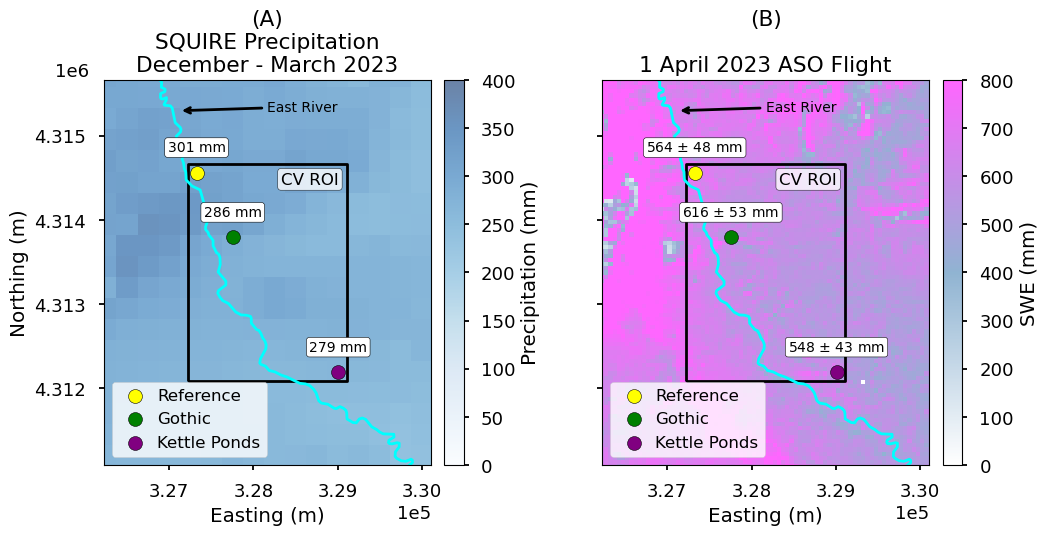

In [55]:
# plot flight with rectangle
fig, axs = plt.subplots(figsize=(15,5), ncols=2, sharey=True)
# horizontal space between subplots
plt.subplots_adjust(wspace=-0.25)
plt.style.use('seaborn-v0_8-talk')
ax = axs[0]

bb_val = int(snowfall_rxr_2023.sel(x=billy_barr_gdf.geometry.x.values[0]+250, y=billy_barr_gdf.geometry.y.values[0]+250, method="nearest").values)
gothic_val = int(snowfall_rxr_2023.sel(x=gothic_gdf.geometry.x.values[0], y=gothic_gdf.geometry.y.values[0], method="nearest").values)
kettle_ponds_val = int(snowfall_rxr_2023.sel(x=kettle_ponds_gdf.geometry.x.values[0], y=kettle_ponds_gdf.geometry.y.values[0]+500, method="nearest").values)

# add hillshade
# topo['hillshade_gray'].plot(ax=ax, 
#                         cmap='gray', 
#                         vmin=0, 
#                         vmax=255,
#                         # turn off colorbar
#                         add_colorbar=False)

(snowfall_rxr_2023).plot(ax=ax, cmap='Blues', vmin=0, vmax=400, cbar_kwargs={'label': 'Precipitation (mm)', 'extend':'neither', 'pad':0.02}, alpha=0.6)
site_rect.boundary.plot(ax=ax, color='black', linewidth=2)
# add text with the CV value
# ax.text(site_rect.geometry.values[0].centroid.x, site_rect.geometry.values[0].centroid.y,
#         f"CV: {cv_2023:.2f}", color='black', fontsize=12, ha='center',
#         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.2'))

billy_barr_gdf.plot(ax=ax, color='yellow', ec='black', markersize=100, label='Reference')
ax.text(billy_barr_gdf.geometry.x.values[0], 
        billy_barr_gdf.geometry.y.values[0]+250, f"{bb_val} mm", color='black',
        bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.2'),
        ha='center')
gothic_gdf.plot(ax=ax, color='green', ec='black', markersize=100, label='Gothic')
ax.text(gothic_gdf.geometry.x.values[0], 
        gothic_gdf.geometry.y.values[0]+250, f"{gothic_val} mm", color='black',
        bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.2'),
        ha='center')
kettle_ponds_gdf.plot(ax=ax, color='purple', ec='black', markersize=100, label='Kettle Ponds')
ax.text(kettle_ponds_gdf.geometry.x.values[0], 
        kettle_ponds_gdf.geometry.y.values[0]+250, f"{kettle_ponds_val} mm",
        color='black',
        bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.2'),
        ha='center')

ax.legend(loc='lower left', handletextpad=0.3, fontsize=12)
ax.set_xlim(minx-1000, maxx+1000)
ax.set_xlabel("Easting (m)")
ax.set_ylim(miny-1000, maxy+1000)
ax.set_ylabel("Northing (m)")
ax.set_title("(A)\nSQUIRE Precipitation\nDecember - March 2023")
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
offset = ax.yaxis.get_offset_text()
offset.set_position((-.15, .95))  # adjust x, y in axes coordinates

ax = axs[1]

flight = aso_flight_2023*1000

bb_val = int(flight.sel(x=billy_barr_gdf.geometry.x.values[0], y=billy_barr_gdf.geometry.y.values[0], method="nearest").values)
gothic_val = int(flight.sel(x=gothic_gdf.geometry.x.values[0], y=gothic_gdf.geometry.y.values[0], method="nearest").values)
kettle_ponds_val = int(flight.sel(x=kettle_ponds_gdf.geometry.x.values[0], y=kettle_ponds_gdf.geometry.y.values[0], method="nearest").values)

# get the max and min of surrounding cells around each point
bb_surrounding = int(flight.sel(x=slice(billy_barr_gdf.geometry.x.values[0]-100, billy_barr_gdf.geometry.x.values[0]+100), 
                            y=slice(billy_barr_gdf.geometry.y.values[0]+100, billy_barr_gdf.geometry.y.values[0]-100)).std().values)
gothic_surrounding = int(flight.sel(x=slice(gothic_gdf.geometry.x.values[0]-100, gothic_gdf.geometry.x.values[0]+100), 
                                y=slice(gothic_gdf.geometry.y.values[0]+100, gothic_gdf.geometry.y.values[0]-100)).std().values)
kettle_ponds_surrounding = int(flight.sel(x=slice(kettle_ponds_gdf.geometry.x.values[0]-100, kettle_ponds_gdf.geometry.x.values[0]+100), 
                                      y=slice(kettle_ponds_gdf.geometry.y.values[0]+100, kettle_ponds_gdf.geometry.y.values[0]-100)).std().values)

# add hillshade
# topo['hillshade_gray'].plot(ax=ax, 
#                         cmap='gray', 
#                         vmin=0, 
#                         vmax=255,
#                         # turn off colorbar
#                         add_colorbar=False)

# plot flight with rectangle
(flight).plot(ax=ax, cmap=custom_cmap, vmin=0, vmax=800, cbar_kwargs={'label': 'SWE (mm)', 'extend':'neither', 'pad':0.02}, alpha=0.6)

site_rect.boundary.plot(ax=ax, color='black', linewidth=2)
# crop to roi
aso_flight_2023_roi = aso_flight_2023.rio.clip(roi_gdf.geometry, roi_gdf.crs)
aso_cv_2023 = (aso_flight_2023_roi.std() / aso_flight_2023_roi.mean()).values
# ax.text(site_rect.geometry.values[0].centroid.x, site_rect.geometry.values[0].centroid.y,
#         f"CV: {aso_cv_2023:.2f}", color='black', fontsize=12, ha='center',
#         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.2'))

billy_barr_gdf.plot(ax=ax, color='yellow', ec='black', markersize=100, label='Reference')
ax.text(billy_barr_gdf.geometry.x.values[0], 
        billy_barr_gdf.geometry.y.values[0]+250, f"{bb_val} $\pm$ {bb_surrounding} mm", color='black',
        bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.2'),
        ha='center')
gothic_gdf.plot(ax=ax, color='green', ec='black', markersize=100, label='Gothic')
ax.text(gothic_gdf.geometry.x.values[0], 
        gothic_gdf.geometry.y.values[0]+250, f"{gothic_val} $\pm$ {gothic_surrounding} mm", color='black',
        bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.2'),
        ha='center')
kettle_ponds_gdf.plot(ax=ax, color='purple', ec='black', markersize=100, label='Kettle Ponds')
ax.text(kettle_ponds_gdf.geometry.x.values[0], 
        kettle_ponds_gdf.geometry.y.values[0]+250, f"{kettle_ponds_val} $\pm$ {kettle_ponds_surrounding} mm",
        color='black',
        bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.2'),
        ha='center')


ax.legend(loc='lower left', handletextpad=0.3, fontsize=12)
ax.set_xlim(minx-1000, maxx+1000)
ax.set_xlabel("Easting (m)")
ax.set_ylim(miny-1000, maxy+1000)
# make x ticks scientific notation
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax.set_ylabel("")
ax.set_title("(B)\n\n1 April 2023 ASO Flight")

for ax in axs:
    ax.text(0.63, 0.73, "CV ROI", transform=ax.transAxes, fontsize=12, color='black',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.2'),
        ha='center')
    # plot flow lines
    flow_lines.plot(ax=ax, color='cyan', linewidth=2,)
    # annotate with arrow and text in axes coordinates
    ax.annotate('East River', xy=(0.23, 0.92),
            xycoords='axes fraction',
            xytext=(0.5, 0.92),
            textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

fig.savefig("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/for_manuscript/squire_vs_aso_precipitation_comparison_2023.png", dpi=600, bbox_inches='tight')

## Method 2: Difference evaluation

In [21]:
quantiles = [5, 50, 95]

def difference_in_medians(x,y, quantiles,instrument):
    q_x = np.quantile(x, np.array(quantiles)/100)
    q_y = np.quantile(y, np.array(quantiles)/100)
    q_diff = q_x - q_y
    q_xy = np.quantile(x - y, np.array(quantiles)/100)

    # calculate confidence intervals using bootstrapping
    n_bootstrap = 1000
    boot_diffs = {q: [] for q in quantiles}
    for _ in range(n_bootstrap):
        x_sample = np.random.choice(x, size=len(x), replace=True)
        y_sample = np.random.choice(y, size=len(y), replace=True)
        for q in quantiles:
            q_x_sample = np.quantile(x_sample, q/100)
            q_y_sample = np.quantile(y_sample, q/100)
            boot_diffs[q].append(q_x_sample - q_y_sample)
    ci_lower = np.percentile(boot_diffs[quantiles[1]], 2.5)
    ci_upper = np.percentile(boot_diffs[quantiles[1]], 97.5)
    return q_diff[1], q_xy[1], ci_lower, ci_upper
    
def calculate_ks_test(x,y,instrument):
    ks_stat, p_value = stats.ks_2samp(x, y)
    if p_value < 0.05:
        print(f"The distributions of {instrument} are significantly different (p < 0.05).")
    else:
        print(f"The distributions of {instrument} are not significantly different (p >= 0.05).")
    return ks_stat

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

def max_cdf_difference(x, y):
    x_ecdf_x, x_ecdf_y = ecdf(x)
    y_ecdf_x, y_ecdf_y = ecdf(y)
    # Evaluate both CDFs on a common grid
    grid = np.sort(np.unique(np.concatenate([x_ecdf_x, y_ecdf_x])))

    Fxg = np.searchsorted(x_ecdf_x, grid, side="right") / len(x_ecdf_x)
    Fyg = np.searchsorted(y_ecdf_x, grid, side="right") / len(y_ecdf_x)
    
    ks_effect = np.max(np.abs(Fxg - Fyg))

    cdf_diff = np.abs(Fxg - Fyg)
    integrated_cdf_diff = np.trapezoid(cdf_diff, grid)

    # Weight differences toward the upper tail
    weights = 1 - 0.5 * (Fxg + Fyg)
    tail_weighted_diff = np.trapezoid(cdf_diff * weights, grid)
    
    return ks_effect, integrated_cdf_diff, tail_weighted_diff

def zero_fraction(x,y):
    zero_frac_x = np.sum(x.values == 0) / len(x.values)
    zero_frac_y = np.sum(y.values == 0) / len(y.values)

    return zero_frac_x, zero_frac_y

In [16]:
def get_dataset(site, directory, time_slice=None):
    """Load dataset for a given site."""
    # precipitation datasets
    gothic_prcp_ds = xr.open_dataset(directory / f'{site}_precipitation_30min.nc')
    era5_land_prcp_ds = xr.open_dataset(directory / f'ERA5-Land/era5_land_gothic_1hr.nc')
    prism_prcp_ds = xr.open_dataset(directory / f'PRISM/prism_site_data.nc').sel(site=site)
    # merge datasets
    ds = xr.merge([gothic_prcp_ds, era5_land_prcp_ds, prism_prcp_ds], compat='override')
    if time_slice is not None:
        ds = ds.sel(time=time_slice)
    # rename tp to ERA5-Land and ppt to PRISM for clarity
    ds = ds.rename({'tp':'ERA5-Land', 'ppt':'PRISM'})
    # drop crs datavar if it exists
    if 'crs' in ds.data_vars:
        ds = ds.drop_vars('crs')
    return ds

In [17]:
DATA_DIR = Path("/storage/dlhogan/precipitation-rodeo/data/processed/final/")
OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/")


In [38]:
time_slice = slice('2021-10-01','2023-06-12')
gothic_ds = get_dataset('gothic', DATA_DIR)
ld_gothic_with_0 = gothic_ds['sail_ld_uncorrected'].sel(time=time_slice)
wb_gothic_with_0 = gothic_ds['sail_pluvio'].sel(time=time_slice)

kettle_ponds_ds = get_dataset('kettle_ponds', DATA_DIR)
ld_kettle_ponds_with_0 = kettle_ponds_ds['splash_ld_uncorrected'].sel(time=time_slice)
wb_kettle_ponds_with_0 = kettle_ponds_ds['splash_pluvio'].sel(time=time_slice)

# take the natural log of all values
ld_gothic_log = np.log(ld_gothic_with_0[ld_gothic_with_0 > 0])
wb_gothic_log = np.log(wb_gothic_with_0[wb_gothic_with_0 > 0])
ld_kettle_ponds_log = np.log(ld_kettle_ponds_with_0[ld_kettle_ponds_with_0 > 0])
wb_kettle_ponds_log = np.log(wb_kettle_ponds_with_0[wb_kettle_ponds_with_0 > 0])

# remove zeros for non-log comparisons
ld_gothic = ld_gothic_with_0[ld_gothic_with_0 > 0]
wb_gothic = wb_gothic_with_0[wb_gothic_with_0 > 0]
ld_kettle_ponds = ld_kettle_ponds_with_0[ld_kettle_ponds_with_0 > 0]
wb_kettle_ponds = wb_kettle_ponds_with_0[wb_kettle_ponds_with_0 > 0]

cdf_comparison_results = {}

instruments = {
    'Laser Disdrometer': (ld_gothic, ld_kettle_ponds),
    'Weighing Bucket': (wb_gothic, wb_kettle_ponds),
    'Laser Disdrometer (log-transformed)': (ld_gothic_log, ld_kettle_ponds_log),
    'Weighing Bucket (log-transformed)': (wb_gothic_log, wb_kettle_ponds_log),
    'Laser Disdrometer (with zeros)': (ld_gothic_with_0, ld_kettle_ponds_with_0),
    'Weighing Bucket (with zeros)': (wb_gothic_with_0, wb_kettle_ponds_with_0)
}

for instrument, (data_gothic, data_kettle_ponds) in instruments.items():
    print(f"\nAnalyzing instrument: {instrument}")
    
    # Quantile differences
    q_diff, q_xy, ci_lower, ci_upper = difference_in_medians(data_gothic, data_kettle_ponds, quantiles, instrument)
    
    # KS test
    ks_stat = calculate_ks_test(data_gothic.resample(time='1D').sum().dropna(dim='time'), data_kettle_ponds.resample(time='1D').sum().dropna(dim='time'), instrument)
    
    # Max CDF difference and related metrics
    ks_effect, integrated_cdf_diff, tail_weighted_diff = max_cdf_difference(data_gothic, data_kettle_ponds)
    
    # Zero fraction comparison
    zero_frac_x, zero_frac_y = zero_fraction(data_gothic, data_kettle_ponds)
    
    # Store results
    cdf_comparison_results[instrument] = {
        'median_difference': np.round(q_diff,3),
        'median_difference_ci': (np.round(ci_lower,3), np.round(ci_upper,3)),
        'ks_statistic': np.round(ks_stat,3),
        'ks_effect_size': np.round(ks_effect,3),
        'integrated_cdf_difference': np.round(integrated_cdf_diff,3),
        'tail_weighted_difference': np.round(tail_weighted_diff,3),
        'zero_fraction_diff': np.round(zero_frac_x,3) - np.round(zero_frac_y,3),
    }

# create a DataFrame to summarize results
summary_df = pd.DataFrame.from_dict(cdf_comparison_results, orient='index').T

# save summary to CSV
summary_df.to_csv(OUTPUT_DIR / "cdf_comparison_summary_kettle_ponds_vs_gothic.csv")


Analyzing instrument: Laser Disdrometer
The distributions of Laser Disdrometer are not significantly different (p >= 0.05).

Analyzing instrument: Weighing Bucket
The distributions of Weighing Bucket are not significantly different (p >= 0.05).

Analyzing instrument: Laser Disdrometer (log-transformed)
The distributions of Laser Disdrometer (log-transformed) are not significantly different (p >= 0.05).

Analyzing instrument: Weighing Bucket (log-transformed)
The distributions of Weighing Bucket (log-transformed) are significantly different (p < 0.05).

Analyzing instrument: Laser Disdrometer (with zeros)
The distributions of Laser Disdrometer (with zeros) are not significantly different (p >= 0.05).

Analyzing instrument: Weighing Bucket (with zeros)
The distributions of Weighing Bucket (with zeros) are not significantly different (p >= 0.05).


### Compare average wind speeds at each site

In [156]:
DATA_DIR = Path("/storage/dlhogan/precipitation-rodeo/data/processed")
gothic_met_ds = xr.open_dataset(DATA_DIR / "SAIL" / "met_30min.nc")
kettlePonds_met_ds = xr.open_dataset(DATA_DIR / "SPLASH" / "asfs30_30min.nc")
billy_met_ds = xr.open_dataset(DATA_DIR / "billy_barr" / "billy_barr_20211001-20230930_30min.nc")
sos_met_ds = xr.open_dataset(DATA_DIR / "SOS" / "sos_ds_30min.nc")

In [ ]:
kettlePonds_met_ds['windSpeed'] = np.sqrt(kettlePonds_met_ds['wspd_u_mean']**2 + kettlePonds_met_ds['wspd_v_mean']**2)

def estimate_wind_at_height(u_measured, z_measured, z_target, z0=0.05):
    """Convert wind speed to different height using logarithmic profile.
    
    z0 (roughness) estimates:
    - Snow/ice: 0.01-0.02 m
    - Grass: 0.05-0.10 m  
    - Forest: 0.5-1.0 m
    """
    u_target = u_measured * np.log(z_target/z0) / np.log(z_measured/z0)
    return u_target

kettlePonds_met_ds['windSpeed_10m_log'] = estimate_wind_at_height(kettlePonds_met_ds['windSpeed'], 4.62, 10)

In [154]:
# billy wind speed 
billy_windSpeed = billy_met_ds['windSpeed'].sel(time=slice('2021-10-01','2023-06-12'))
billy_windSpeed_mean = billy_windSpeed.mean()
billy_windSpeed_std = billy_windSpeed.std()
billy_windSpeed_cv = billy_windSpeed_std / billy_windSpeed_mean

# gothic wind speed
gothic_windSpeed = gothic_met_ds['wspd_vec_mean'].sel(time=slice('2021-10-01','2023-06-12'))
gothic_windSpeed_mean = gothic_windSpeed.mean()
gothic_windSpeed_std = gothic_windSpeed.std()
gothic_windSpeed_cv = gothic_windSpeed_std / gothic_windSpeed_mean

# kettle ponds wind speed
kettle_windSpeed = kettlePonds_met_ds['windSpeed_10m_log'].sel(time=slice('2021-10-01','2023-06-12'))
kettle_windSpeed_mean = kettle_windSpeed.mean()
kettle_windSpeed_std = kettle_windSpeed.std()
kettle_windSpeed_cv = kettle_windSpeed_std / kettle_windSpeed_mean

# combine into a single DataFrame for plotting
wind_speed_df = pd.DataFrame({
    'Billy Barr': [billy_windSpeed_mean.values, billy_windSpeed_std.values, billy_windSpeed_cv.values],
    'Gothic': [gothic_windSpeed_mean.values, gothic_windSpeed_std.values, gothic_windSpeed_cv.values],
    'Kettle Ponds': [kettle_windSpeed_mean.values, kettle_windSpeed_std.values, kettle_windSpeed_cv.values]
}, index=['Mean', 'Std Dev', 'Coefficient of Variation'])
wind_speed_df

,Billy Barr,Gothic,Kettle Ponds
Mean,1.156259166252242,2.176589879132386,3.0661037511822316
Std Dev,0.8810642471134684,1.5193226921264356,2.211466515626717
Coefficient of Variation,0.7619954702449998,0.6980289243704723,0.7212627800915143
